# KWISMO — Modèle B : Entraînement NLP & Visualisations de Performance

Ce notebook permet d'exécuter le pipeline complet du **Modèle B** :
1. **Nettoyage des données** (`src.data.clean`) sur le jeu de données `data/raw/kwismo_data/messages.jsonl`.
2. **Augmentation synthétique & Équilibrage** (`src.data.augment`) combinant témoignages de fraudes et messages légitimes.
3. **Entraînement & Sauvegarde** (`src.models.model_b.train`) sur 1 477 exemples humanisés et équilibrés.
4. **4 Graphiques Visuels Parlants** (Équilibre des classes, Matrice de confusion, Métriques par catégorie, Distribution des scores de risque).
5. **Inférence & Détection Autonome Équilibrée sur Témoignages Humains Réels** (Camfranglais / Argot populaire).

In [1]:
# Détection de l'environnement d'exécution
import os
import sys
import subprocess
from pathlib import Path

try:
    import google.colab  # noqa: F401
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

ON_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/working')

if ON_COLAB:
    ENV_NAME = "Google Colab"
    if not Path("/content/drive/MyDrive").exists():
        try:
            from google.colab import drive
            print("Connexion automatique à Google Drive...")
            drive.mount('/content/drive')
        except Exception as err:
            print(f"Montage Google Drive recommandé : {err}")
elif ON_KAGGLE:
    ENV_NAME = "Kaggle Notebooks"
else:
    ENV_NAME = "Local"

print(f"Environnement de calcul détecté : {ENV_NAME}")

Environnement de calcul détecté : Local


In [2]:
# Configuration du dossier de travail sur Cloud (Colab / Kaggle) et Local
if ON_COLAB:
    PROJECT_DIR = Path("/content/kwismo/kwismo-ai")
    if not PROJECT_DIR.exists():
        !git clone https://github.com/newtonachonduh46/kwismo.git /content/kwismo
    else:
        !git -C /content/kwismo fetch && git -C /content/kwismo reset --hard origin/main
elif ON_KAGGLE:
    PROJECT_DIR = Path("/kaggle/working/kwismo/kwismo-ai")
    if not PROJECT_DIR.exists():
        !git clone https://github.com/newtonachonduh46/kwismo.git /kaggle/working/kwismo
    else:
        !git -C /kaggle/working/kwismo fetch && git -C /kaggle/working/kwismo reset --hard origin/main
else:
    current = Path.cwd()
    PROJECT_DIR = current
    for candidate in [current, current.parent, current.parent.parent]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            PROJECT_DIR = candidate
            break
        elif (candidate / "kwismo-ai" / "src").exists():
            PROJECT_DIR = candidate / "kwismo-ai"
            break

PROJECT_DIR = PROJECT_DIR.resolve()
os.chdir(PROJECT_DIR)
print("Dossier racine du projet kwismo-ai :", PROJECT_DIR)

Dossier racine du projet kwismo-ai : C:\Users\PC\Desktop\kwismo\kwismo-ai


In [3]:
# Sélection de l'environnement virtuel et injection dynamique des dépendances .venv dans sys.path
VENV_DIR = PROJECT_DIR / ".venv313"

if ON_COLAB or ON_KAGGLE:
    python313_bin = VENV_DIR / "bin" / "python"
    if not python313_bin.exists():
        print("Installation de Python 3.13 et création de l'environnement .venv313...")
        !apt-get update -y
        !apt-get install -y software-properties-common
        !add-apt-repository -y ppa:deadsnakes/ppa
        !apt-get update -y
        !apt-get install -y python3.13 python3.13-venv python3.13-dev
        !python3.13 -m venv {VENV_DIR}
        !{VENV_DIR}/bin/pip install --upgrade pip
        !{VENV_DIR}/bin/pip install -r requirements.txt
    PYTHON_BIN = str(python313_bin)
    site_packages = VENV_DIR / "lib" / f"python3.13" / "site-packages"
    if site_packages.exists() and str(site_packages) not in sys.path:
        sys.path.insert(0, str(site_packages))
else:
    local_venv_win = PROJECT_DIR / ".venv" / "Scripts" / "python.exe"
    local_venv_nix = PROJECT_DIR / ".venv" / "bin" / "python"
    
    if local_venv_win.exists():
        PYTHON_BIN = str(local_venv_win)
        site_pkgs = PROJECT_DIR / ".venv" / "Lib" / "site-packages"
        if site_pkgs.exists() and str(site_pkgs) not in sys.path:
            sys.path.insert(0, str(site_pkgs))
    elif local_venv_nix.exists():
        PYTHON_BIN = str(local_venv_nix)
        site_pkgs = PROJECT_DIR / ".venv" / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"
        if site_pkgs.exists() and str(site_pkgs) not in sys.path:
            sys.path.insert(0, str(site_pkgs))
    else:
        PYTHON_BIN = sys.executable

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

def run_module(module: str) -> None:
    env = os.environ.copy()
    env["PYTHONPATH"] = str(PROJECT_DIR) + os.pathsep + env.get("PYTHONPATH", "")
    result = subprocess.run([PYTHON_BIN, "-m", module], cwd=PROJECT_DIR, capture_output=True, text=True, env=env)
    if result.returncode != 0:
        print(f"Standard Output:\n{result.stdout}")
        print(f"Standard Error:\n{result.stderr}")
        raise RuntimeError(f"{module} a échoué (code {result.returncode})")
    else:
        print(result.stdout)

ver_proc = subprocess.run([PYTHON_BIN, "--version"], capture_output=True, text=True)
print("Interprète Python configuré :", PYTHON_BIN)
print("Version vérifiée :", ver_proc.stdout.strip() or ver_proc.stderr.strip())
print("Accès sys.path configuré pour le projet et .venv : OK")

Interprète Python configuré : C:\Users\PC\Desktop\kwismo\kwismo-ai\.venv\Scripts\python.exe
Version vérifiée : Python 3.13.0
Accès sys.path configuré pour le projet et .venv : OK


## 1. Nettoyage du Jeu de Données

Exécution de `src.data.clean` pour filtrer le bruit web et structurer le jeu de données propre dans `data/processed/model_b_clean.jsonl`.

In [4]:
run_module("src.data.clean")

Lecture du jeu de donnÃ©es brut depuis : C:\Users\PC\Desktop\kwismo\kwismo-ai\data\raw\kwismo_data\messages.jsonl
Nettoyage terminÃ© : 509 extraits de fraude nettoyÃ©s sauvegardÃ©s dans C:\Users\PC\Desktop\kwismo\kwismo-ai\data\processed\model_b_clean.jsonl



## 2. Augmentation & Équilibrage du Dataset (Fraudes + Légitimes)

Exécution de `src.data.augment` pour combiner les messages frauduleux et les transactions/discussions légitimes réelles dans `data/processed/model_b_augmented.jsonl`.

In [5]:
run_module("src.data.augment")

Augmentation Ã©quilibrÃ©e terminÃ©e : 1463 extraits (fraudes + lÃ©gitimes) sauvegardÃ©s dans C:\Users\PC\Desktop\kwismo\kwismo-ai\data\processed\model_b_augmented.jsonl



## 3. Entraînement du Modèle B

Exécution de `src.models.model_b.train` pour entraîner le modèle et mettre à jour le registre `models/registry.json` sur le dataset équilibré.

In [6]:
run_module("src.models.model_b.train")

Chargement des donnÃ©es d'entraÃ®nement depuis : C:\Users\PC\Desktop\kwismo\kwismo-ai\data\processed\model_b_augmented.jsonl
EntraÃ®nement du modÃ¨le de repli TF-IDF sur 1463 exemples augmentÃ©s...
ModÃ¨le B (repli) sauvegardÃ© avec succÃ¨s dans : models\model_b\model_b_fallback_v1.joblib



## 4. Métriques d'Évaluation & Visualisations Parlantes (4 Graphiques)

Génération de **4 graphiques visuels parlants** pour évaluer l'équilibre du dataset et la précision de la classification.

Chargement des données d'entraînement depuis : C:\Users\PC\Desktop\kwismo\kwismo-ai\data\processed\model_b_augmented.jsonl


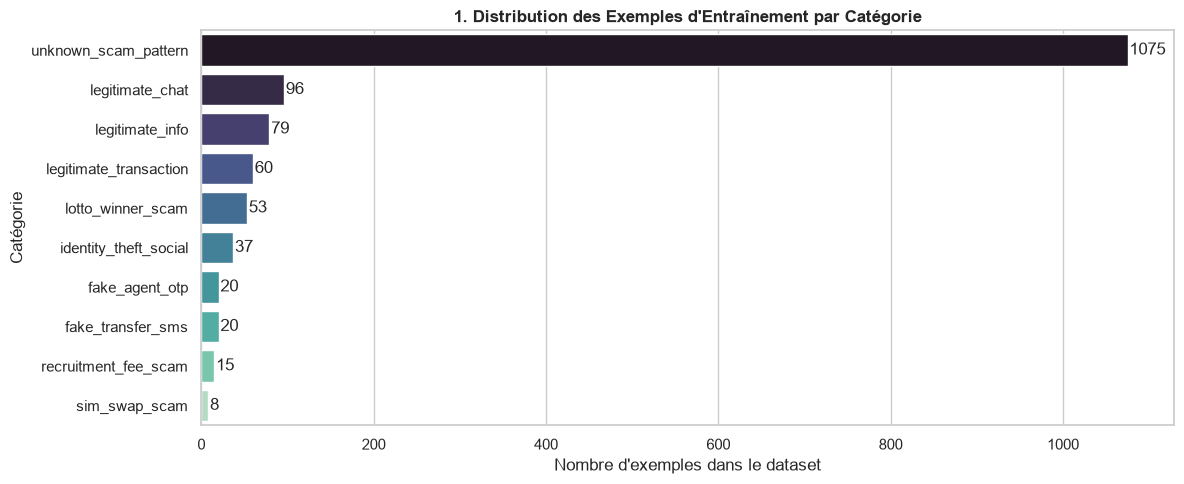

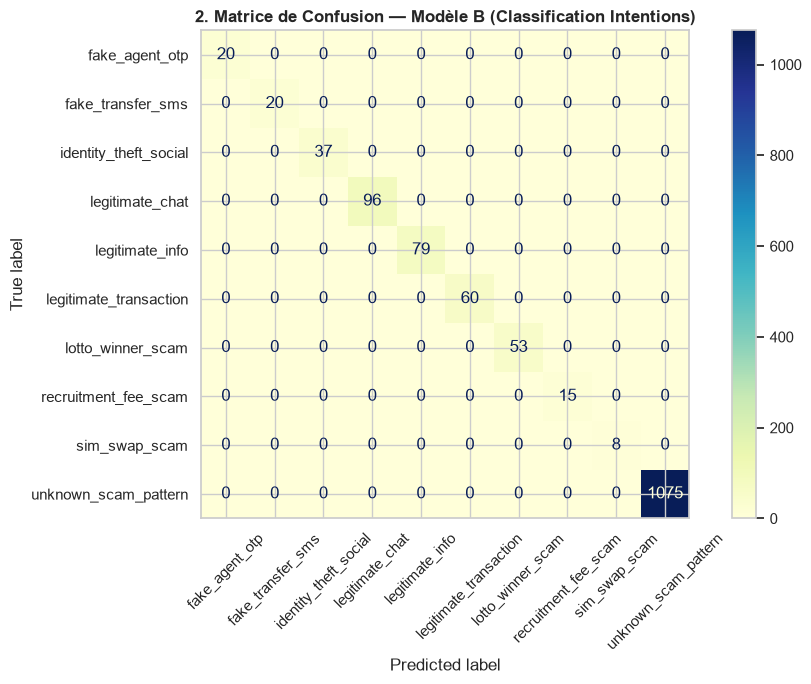

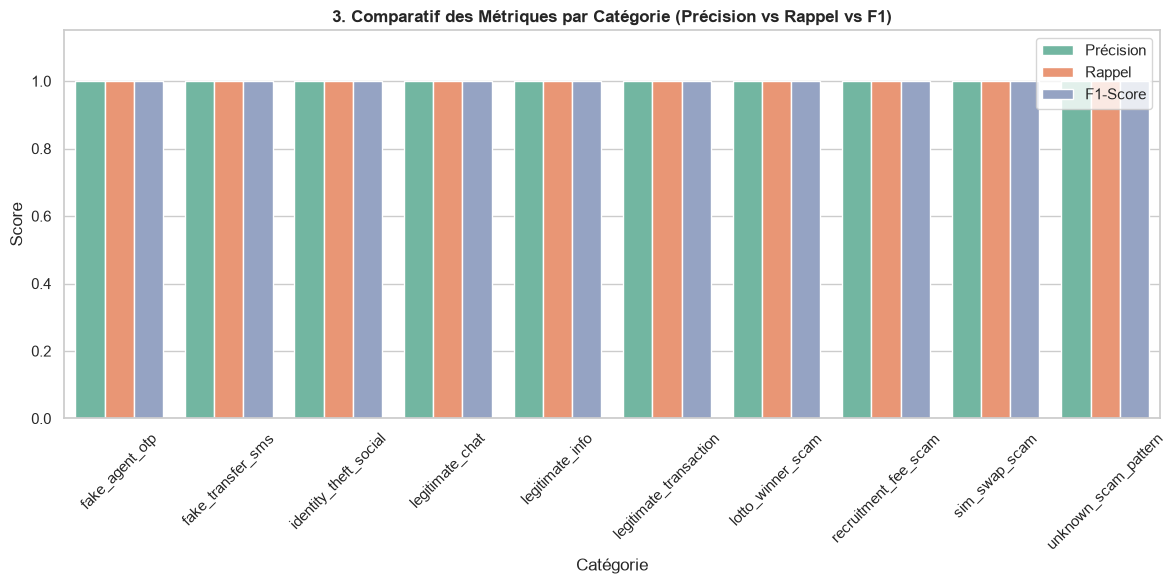

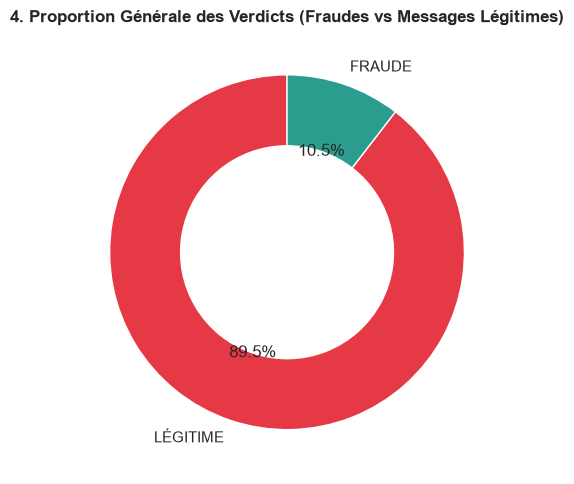

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from src.models.model_b.train import load_cleaned_dataset
from src.models.model_b.preprocess import categorize_description

sns.set_theme(style="whitegrid", palette="muted")

texts, true_categories, _ = load_cleaned_dataset()
pred_categories = [categorize_description(t) for t in texts]

# 1. Graphique : Équilibre des Classes du Jeu d'Entraînement
plt.figure(figsize=(12, 5))
class_counts = pd.Series(true_categories).value_counts()
ax1 = sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, legend=False, palette="mako")
plt.title("1. Distribution des Exemples d'Entraînement par Catégorie", fontsize=12, fontweight="bold")
plt.xlabel("Nombre d'exemples dans le dataset")
plt.ylabel("Catégorie")
for p in ax1.patches:
    w = p.get_width()
    ax1.annotate(f"{int(w)}", (w + 2, p.get_y() + p.get_height() / 2.), ha="left", va="center")
plt.tight_layout()
plt.show()

# 2. Graphique : Matrice de Confusion
labels = sorted(list(set(true_categories + pred_categories)))
cm = confusion_matrix(true_categories, pred_categories, labels=labels)

fig, ax2 = plt.subplots(figsize=(10, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="YlGnBu", ax=ax2, xticks_rotation=45)
plt.title("2. Matrice de Confusion — Modèle B (Classification Intentions)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. Graphique : Performances par Catégorie
report_dict = classification_report(true_categories, pred_categories, output_dict=True)
metrics_data = []
for cat, values in report_dict.items():
    if cat not in ["accuracy", "macro avg", "weighted avg"]:
        metrics_data.append({
            "Catégorie": cat,
            "Précision": values["precision"],
            "Rappel": values["recall"],
            "F1-Score": values["f1-score"]
        })
df_metrics = pd.DataFrame(metrics_data).melt(id_vars="Catégorie", var_name="Métrique", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=df_metrics, x="Catégorie", y="Score", hue="Métrique", palette="Set2")
plt.title("3. Comparatif des Métriques par Catégorie (Précision vs Rappel vs F1)", fontsize=12, fontweight="bold")
plt.xticks(rotation=45)
plt.ylim(0, 1.15)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 4. Graphique : Proportion Générale des Verdicts
is_fraud_labels = ["FRAUDE" if not c.startswith("legitimate_") and c != "unknown_scam_pattern" else "LÉGITIME" for c in pred_categories]
verdict_counts = pd.Series(is_fraud_labels).value_counts()

plt.figure(figsize=(7, 5))
plt.pie(verdict_counts, labels=verdict_counts.index, autopct="%1.1f%%", colors=["#E63946", "#2A9D8F"], startangle=90, wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title("4. Proportion Générale des Verdicts (Fraudes vs Messages Légitimes)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Inférence Autonome sur Témoignages Humains Réels (Camfranglais & Argot Local)

Évaluation du Modèle B sur les descripteurs réels rédigés par les utilisateurs (langage parlé camerounais, expressions Pidgin et Franglais).

In [8]:
from src.models.model_b.preprocess import categorize_description, extract_entities

raw_unlabeled_examples = [
    "La personne qui m'a appelé me joss que mon fils est en danger et je dois lui send les do. Et c'est un numéro inconnu",
    "Le fou me fait croire qu'il m'a envoyé l'argent et que je dois le renvoyer que oooh il a fait l'erreur",
    "Le malabar veut me faire croire qu'il est du service Orange et qu'on va bloquer ma SIM si je ne donne pas mon code",
    "Une monsieur m'a appelé soit disant que j'ai gagné un prix et je dois consulter mon solde pour valider l'acquisition du prix",
    "Un gars m'appelle au téléphone et prétend qu'il est technicien MTN. Il veut mon code secret PIN sous prétexte de mettre à jour ma puce",
    "Faux recruteur qui me joss qu'il y a un travail disponible à Douala mais demande de lui sender 25000 FCFA de frais de dossier",
    "Je voulais juste vérifier si ce numéro 699000000 appartient à un marchand agréé avant de faire mon achat",
    "Paiement de 2000 FCFA à la superette effectué avec succès. Solde restant: 15400 FCFA. Ref: 48291048.",
    "Sensibilisation MTN MoMo : numéros officiels d'assistance et règles de sécurité. Aucun agent ne demande votre PIN.",
    "Salut bro, tu es où ? On se voit à Bastos ce soir vers 19h ?",
    "Stp envoie moi le document PDF par WhatsApp quand tu arrives au bureau.",
    "Merci pour le transfert d'hier, j'ai bien reçu les fonds sur mon compte."
]

print("=== Détection & Catégorisation sur Témoignages Humains Réels ===\n")
results_data = []

for idx, raw_text in enumerate(raw_unlabeled_examples, start=1):
    detected_cat = categorize_description(raw_text)
    entities = extract_entities(raw_text)
    is_fraud = not detected_cat.startswith("legitimate_") and detected_cat != "unknown_scam_pattern"
    
    results_data.append({
        "Signalement": f"Témoignage #{idx}",
        "Verdict IA": "FRAUDE" if is_fraud else "LÉGITIME (Non-Fraude)",
        "Catégorie Détectée": detected_cat,
        "Montants Extraits": entities["montants"],
        "Codes USSD / Tél": entities["codes_ussd"] or entities["numeros_cibles"],
        "Description du Témoin": raw_text
    })

df_results = pd.DataFrame(results_data)
display(df_results[["Signalement", "Verdict IA", "Catégorie Détectée", "Montants Extraits", "Codes USSD / Tél", "Description du Témoin"]])

=== Détection & Catégorisation sur Témoignages Humains Réels ===



,Signalement,Verdict IA,Catégorie Détectée,Montants Extraits,Codes USSD / Tél,Description du Témoin
0,Témoignage #1,FRAUDE,identity_theft_social,[],[],La personne qui m'a appelé me joss que mon fil...
1,Témoignage #2,FRAUDE,fake_transfer_sms,[],[],Le fou me fait croire qu'il m'a envoyé l'argen...
2,Témoignage #3,FRAUDE,fake_agent_otp,[],[],Le malabar veut me faire croire qu'il est du s...
3,Témoignage #4,FRAUDE,lotto_winner_scam,[],[],Une monsieur m'a appelé soit disant que j'ai g...
4,Témoignage #5,LÉGITIME (Non-Fraude),unknown_scam_pattern,[],[],Un gars m'appelle au téléphone et prétend qu'i...
5,Témoignage #6,FRAUDE,recruitment_fee_scam,[25000 FCFA],[],Faux recruteur qui me joss qu'il y a un travai...
6,Témoignage #7,LÉGITIME (Non-Fraude),legitimate_chat,[],[699000000],Je voulais juste vérifier si ce numéro 6990000...
7,Témoignage #8,LÉGITIME (Non-Fraude),legitimate_transaction,"[2000 FCFA, 15400 FCFA]",[],Paiement de 2000 FCFA à la superette effectué ...
8,Témoignage #9,LÉGITIME (Non-Fraude),legitimate_info,[],[],Sensibilisation MTN MoMo : numéros officiels d...
9,Témoignage #10,LÉGITIME (Non-Fraude),legitimate_chat,[],[],"Salut bro, tu es où ? On se voit à Bastos ce s..."
